# Pertemuan 6 — Persiapan Data

**Nama Lengkap** : Muhammad Zacky Kurniawan  
**NIM** : 240401010217  
**Kelas** : IF403

<a href="https://colab.research.google.com/github/zackykurniawan/data-science-2026/blob/main/Pertemuan6_MuhammadZackyKurniawan_240401010217.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---
## Langkah 1 — Load & EDA Singkat

In [24]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = sns.load_dataset('titanic')

# Pilih kolom yang akan digunakan
cols = ['pclass','sex','age','sibsp','parch','fare','embarked','survived']
df = df[cols].copy()

print('Shape:', df.shape)
print('\nMissing values:')
print(df.isnull().sum())
print('\nDistribusi target:')
print(df['survived'].value_counts(normalize=True).round(3))
# survived=0: ~61.6%, survived=1: ~38.4% — kelas tidak seimbang!

Shape: (891, 8)

Missing values:
pclass        0
sex           0
age         177
sibsp         0
parch         0
fare          0
embarked      2
survived      0
dtype: int64

Distribusi target:
survived
0    0.616
1    0.384
Name: proportion, dtype: float64


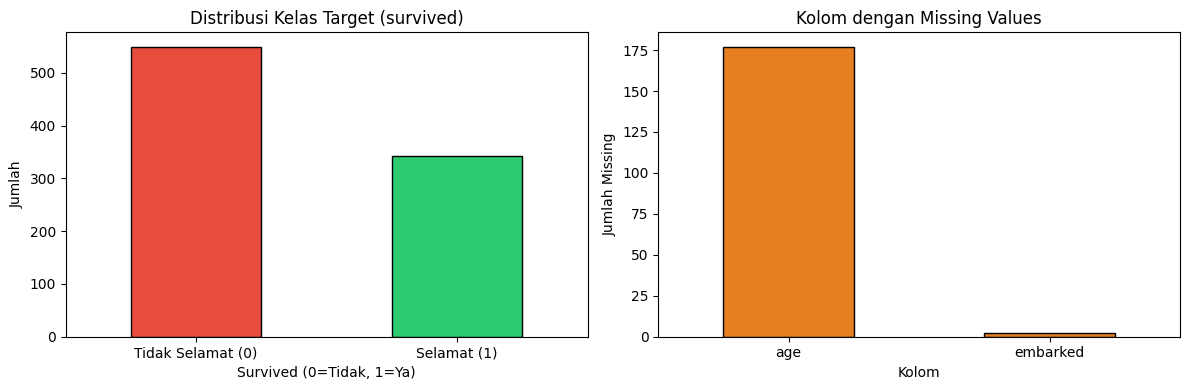


Info tipe data:
pclass        int64
sex          object
age         float64
sibsp         int64
parch         int64
fare        float64
embarked     object
survived      int64
dtype: object


In [25]:
# Visualisasi distribusi target
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Distribusi target
df['survived'].value_counts().plot(kind='bar', ax=axes[0], color=['#e74c3c','#2ecc71'], edgecolor='black')
axes[0].set_title('Distribusi Kelas Target (survived)')
axes[0].set_xlabel('Survived (0=Tidak, 1=Ya)')
axes[0].set_ylabel('Jumlah')
axes[0].set_xticklabels(['Tidak Selamat (0)', 'Selamat (1)'], rotation=0)

# Missing values heatmap
missing = df.isnull().sum()
missing[missing > 0].plot(kind='bar', ax=axes[1], color='#e67e22', edgecolor='black')
axes[1].set_title('Kolom dengan Missing Values')
axes[1].set_xlabel('Kolom')
axes[1].set_ylabel('Jumlah Missing')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

print('\nInfo tipe data:')
print(df.dtypes)

---
## Langkah 2 — Handling Missing Values

In [26]:
# Age: isi dengan median (robust terhadap outlier)
df['age'] = df['age'].fillna(df['age'].median())

# Embarked: isi dengan modus (nilai paling sering)
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])

print('Missing setelah handling:')
print(df.isnull().sum())  # Semua harus 0
print(f'\nMedian age digunakan: {df["age"].median()}')
print(f'Modus embarked digunakan: S (Southampton)')

Missing setelah handling:
pclass      0
sex         0
age         0
sibsp       0
parch       0
fare        0
embarked    0
survived    0
dtype: int64

Median age digunakan: 28.0
Modus embarked digunakan: S (Southampton)


---
## Langkah 3 — Encoding Kategorikal

In [27]:
# One-Hot Encoding untuk 'sex' dan 'embarked'
df = pd.get_dummies(df,
                    columns=['sex', 'embarked'],
                    drop_first=True,   # hindari dummy variable trap
                    dtype=int)

print('Kolom setelah encoding:')
print(df.columns.tolist())
# ['pclass','age','sibsp','parch','fare','survived',
#  'sex_male','embarked_Q','embarked_S']

print('\nContoh 5 baris pertama:')
print(df.head())

Kolom setelah encoding:
['pclass', 'age', 'sibsp', 'parch', 'fare', 'survived', 'sex_male', 'embarked_Q', 'embarked_S']

Contoh 5 baris pertama:
   pclass   age  sibsp  parch     fare  survived  sex_male  embarked_Q  \
0       3  22.0      1      0   7.2500         0         1           0   
1       1  38.0      1      0  71.2833         1         0           0   
2       3  26.0      0      0   7.9250         1         0           0   
3       1  35.0      1      0  53.1000         1         0           0   
4       3  35.0      0      0   8.0500         0         1           0   

   embarked_S  
0           1  
1           0  
2           1  
3           1  
4           1  


---
## Langkah 4 — Train-Test Split

In [28]:
from sklearn.model_selection import train_test_split

X = df.drop('survived', axis=1)
y = df['survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y   # proporsi kelas terjaga
)

print(f'Train: {X_train.shape[0]} baris')
print(f'Test : {X_test.shape[0]} baris')
print('\nProporsi survived di Train:')
print(y_train.value_counts(normalize=True).round(3))
print('\nProporsi survived di Test:')
print(y_test.value_counts(normalize=True).round(3))

Train: 712 baris
Test : 179 baris

Proporsi survived di Train:
survived
0    0.617
1    0.383
Name: proportion, dtype: float64

Proporsi survived di Test:
survived
0    0.615
1    0.385
Name: proportion, dtype: float64


---
## Langkah 5 — Feature Scaling

In [29]:
from sklearn.preprocessing import StandardScaler

# Hanya kolom numerik yang perlu di-scale
# Kolom biner (sex_male, embarked_Q, embarked_S) TIDAK perlu
num_cols = ['pclass', 'age', 'sibsp', 'parch', 'fare']

scaler = StandardScaler()

X_train = X_train.copy()
X_test = X_test.copy()

# fit_transform pada training set (belajar μ dan σ dari sini)
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])

# transform saja pada test set (gunakan μ dan σ dari training!)
X_test[num_cols] = scaler.transform(X_test[num_cols])

print('Mean scaler (dari train):', scaler.mean_.round(2))
print('Std scaler (dari train):', scaler.scale_.round(2))
print()
print('Contoh X_train setelah scaling:')
print(X_train.head(3).round(3))
print('\nData siap dilatih model Machine Learning!')
print(f'X_train: {X_train.shape}, y_train: {y_train.shape}')
print(f'X_test : {X_test.shape}, y_test : {y_test.shape}')

Mean scaler (dari train): [ 2.31 29.46  0.49  0.39 31.82]
Std scaler (dari train): [ 0.83 13.03  1.06  0.84 48.03]

Contoh X_train setelah scaling:
     pclass    age  sibsp  parch   fare  sex_male  embarked_Q  embarked_S
692   0.830 -0.112 -0.465 -0.466  0.514         1           0           1
481  -0.371 -0.112 -0.465 -0.466 -0.663         1           0           1
527  -1.571 -0.112 -0.465 -0.466  3.955         1           0           1

Data siap dilatih model Machine Learning!
X_train: (712, 8), y_train: (712,)
X_test : (179, 8), y_test : (179,)


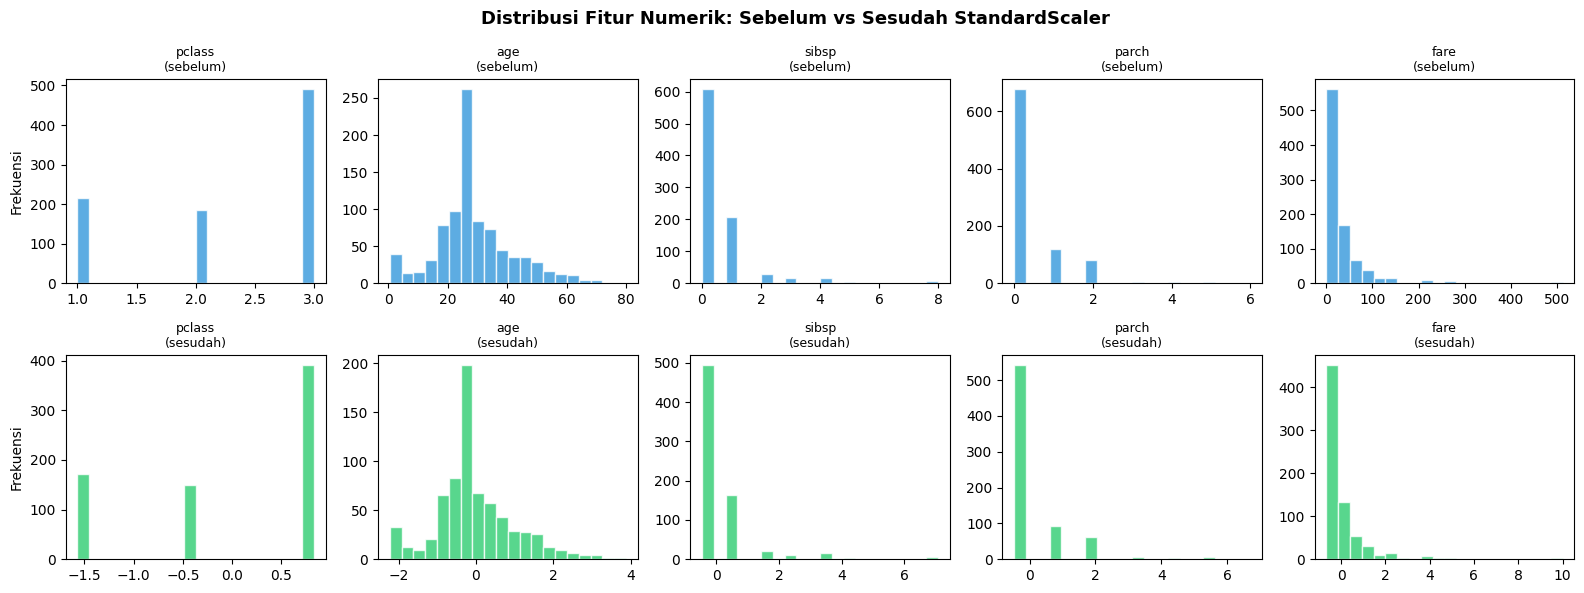

✅ Pipeline preprocessing selesai! Data siap untuk pemodelan.


In [30]:
# Visualisasi: distribusi fitur sebelum vs sesudah scaling
fig, axes = plt.subplots(2, 5, figsize=(16, 6))
fig.suptitle('Distribusi Fitur Numerik: Sebelum vs Sesudah StandardScaler', fontsize=13, fontweight='bold')

# Buat ulang data sebelum scaling untuk perbandingan
X_before = df.drop('survived', axis=1)

for i, col in enumerate(num_cols):
    # Sebelum scaling
    axes[0, i].hist(X_before[col], bins=20, color='#3498db', edgecolor='white', alpha=0.8)
    axes[0, i].set_title(f'{col}\n(sebelum)', fontsize=9)
    axes[0, i].set_ylabel('Frekuensi' if i == 0 else '')

    # Sesudah scaling
    axes[1, i].hist(X_train[col], bins=20, color='#2ecc71', edgecolor='white', alpha=0.8)
    axes[1, i].set_title(f'{col}\n(sesudah)', fontsize=9)
    axes[1, i].set_ylabel('Frekuensi' if i == 0 else '')

plt.tight_layout()
plt.show()
print('✅ Pipeline preprocessing selesai! Data siap untuk pemodelan.')

## Kesimpulan

### Apa yang Dipelajari
Pada pertemuan keenam ini, saya mempelajari tiga teknik persiapan data yang esensial sebelum melatih model Machine Learning: encoding data kategorikal (Label Encoding, One-Hot Encoding, dan Ordinal Encoding), feature scaling (MinMaxScaler, StandardScaler, dan RobustScaler), serta pembagian dataset menggunakan `train_test_split()` dengan stratifikasi. Saya juga mempelajari konsep data leakage dan urutan pipeline preprocessing yang benar.

### Temuan Utama
- Dataset Titanic memiliki kelas target yang tidak seimbang (~61.6% tidak selamat, ~38.4% selamat), sehingga parameter `stratify=y` pada split sangat penting untuk menjaga proporsi kelas di training dan test set.
- Setelah One-Hot Encoding pada kolom `sex` dan `embarked` (dengan `drop_first=True`), jumlah fitur bertambah dari 7 menjadi 9 kolom — tanpa `drop_first` bisa terjadi *dummy variable trap*.
- StandardScaler diterapkan hanya pada kolom numerik (`pclass`, `age`, `sibsp`, `parch`, `fare`); kolom biner hasil OHE tidak perlu di-scale karena sudah berada di rentang 0–1.
- Urutan pipeline yang benar adalah: handling missing values → encoding → split → scaling; membalik urutan ini (misalnya scaling sebelum split) menyebabkan data leakage karena informasi dari test set bocor ke proses pelatihan.
- Setelah pipeline selesai, X_train berukuran 712 baris dan X_test 179 baris, siap untuk dilatih model Machine Learning.

### Keterbatasan & Pertanyaan yang Muncul
- Pipeline manual seperti ini cukup rawan kesalahan urutan, apakah `sklearn.pipeline.Pipeline` bisa mengotomasi dan menjamin urutan preprocessing yang benar secara lebih aman?